In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, log_loss, r2_score, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder


import xgboost as xgb
import seaborn as sns
# import hyperopt as hp
pd.set_option('display.max_columns', 999)
pd.set_option('display.max_rows', 999)


NameError: name 'pkg_resources' is not defined

In [ ]:
df_spotify = pd.read_csv('merged.csv')
df_spotify.info()
df_spotify.sample(5)



<class 'pandas.DataFrame'>
RangeIndex: 4831 entries, 0 to 4830
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   energy                    4830 non-null   float64
 1   tempo                     4830 non-null   float64
 2   danceability              4830 non-null   float64
 3   playlist_genre            4831 non-null   str    
 4   loudness                  4830 non-null   float64
 5   liveness                  4830 non-null   float64
 6   valence                   4830 non-null   float64
 7   track_artist              4831 non-null   str    
 8   time_signature            4830 non-null   float64
 9   speechiness               4830 non-null   float64
 10  track_popularity          4831 non-null   int64  
 11  track_href                4830 non-null   str    
 12  uri                       4830 non-null   str    
 13  track_album_name          4830 non-null   str    
 14  playlist_name      

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,track_popularity,track_href,uri,track_album_name,playlist_name,analysis_url,track_id,track_name,track_album_release_date,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
4383,0.685,120.971,0.840,electronic,-3.431,0.0594,0.267,Booba,4.0,0.0591,44,https://api.spotify.com/v1/tracks/6ZEMbp1RZ1iM...,spotify:track:6ZEMbp1RZ1iMkQOufEbzNC,Trône,French Touch,https://api.spotify.com/v1/audio-analysis/6ZEM...,6ZEMbp1RZ1iMkQOufEbzNC,E.L.E.P.H.A.N.T - Bonus Track,2017-12-01,0.000062,2RO5bTmlRq3rlloElsZqVl,0.0,6.0,179773.0,0.1930,6ZEMbp1RZ1iMkQOufEbzNC,french,audio_features,58zteW83Lvl8e158fCCFVN
4120,0.741,108.088,0.542,hip-hop,-7.875,0.5380,0.189,"Bashy, GRM Daily",3.0,0.3450,38,https://api.spotify.com/v1/tracks/1Iow5wEoOZ8g...,spotify:track:1Iow5wEoOZ8gAPZTSNI8HQ,Being Poor is Expensive,Grime Shutdown,https://api.spotify.com/v1/audio-analysis/1Iow...,1Iow5wEoOZ8gAPZTSNI8HQ,Sticky,2024-07-11,0.000000,0jENGMvmnPYqxQ4M6qE022,1.0,1.0,192205.0,0.0643,1Iow5wEoOZ8gAPZTSNI8HQ,grime,audio_features,37i9dQZF1DWSOkubnsDCSS
123,0.549,176.941,0.516,rock,-13.741,0.1840,0.907,Don Henley,4.0,0.0373,73,https://api.spotify.com/v1/tracks/4gvea7UlDkAv...,spotify:track:4gvea7UlDkAvsJBPZAd4oB,Building The Perfect Beast,Rock Classics,https://api.spotify.com/v1/audio-analysis/4gve...,4gvea7UlDkAvsJBPZAd4oB,The Boys Of Summer,1984-11-19,0.005720,2x1s5aVQ01ylPs5nUdeA2i,1.0,6.0,288733.0,0.5010,4gvea7UlDkAvsJBPZAd4oB,classic,audio_features,37i9dQZF1DWXRqgorJj26U
4774,0.672,127.018,0.681,pop,-5.166,0.2800,0.297,EMMY,4.0,0.0421,30,https://api.spotify.com/v1/tracks/05tsYovIC8rT...,spotify:track:05tsYovIC8rTfpCChklKeu,Dear Sandman,Scandi Pop,https://api.spotify.com/v1/audio-analysis/05ts...,05tsYovIC8rTfpCChklKeu,Dear Sandman,2022-10-28,0.000000,73c6tjL61vGbmbrdDX7QQ3,1.0,5.0,141480.0,0.0463,05tsYovIC8rTfpCChklKeu,scandi,audio_features,59z06GgF6TTDbm5cr1RZUC
904,0.902,84.412,0.573,pop,-7.638,0.0928,0.876,a-ha,4.0,0.0540,84,https://api.spotify.com/v1/tracks/2WfaOiMkCvy7...,spotify:track:2WfaOiMkCvy7F5fcp2zZ8L,Hunting High and Low,Throwback Party,https://api.spotify.com/v1/audio-analysis/2Wfa...,2WfaOiMkCvy7F5fcp2zZ8L,Take on Me,1985-06-01,0.001250,1ER3B6zev5JEAaqhnyyfbf,0.0,6.0,225280.0,0.0180,2WfaOiMkCvy7F5fcp2zZ8L,throwback,audio_features,37i9dQZF1DX7F6T2n2fegs


In [ ]:
ft_space1 = ['energy', 'danceability', 'speechiness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'mode', 'key', 'time_signature']

In [ ]:
df_spotify['playlist_genre'] = df_spotify['playlist_genre'].astype('category')
df_spotify['playlist_subgenre'] = df_spotify['playlist_subgenre'].astype('category')

In [ ]:
df_spotify.info()


<class 'pandas.DataFrame'>
RangeIndex: 4831 entries, 0 to 4830
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   energy                    4830 non-null   float64 
 1   tempo                     4830 non-null   float64 
 2   danceability              4830 non-null   float64 
 3   playlist_genre            4831 non-null   category
 4   loudness                  4830 non-null   float64 
 5   liveness                  4830 non-null   float64 
 6   valence                   4830 non-null   float64 
 7   track_artist              4831 non-null   str     
 8   time_signature            4830 non-null   float64 
 9   speechiness               4830 non-null   float64 
 10  track_popularity          4831 non-null   int64   
 11  track_href                4830 non-null   str     
 12  uri                       4830 non-null   str     
 13  track_album_name          4830 non-null   str     
 14  pla

In [ ]:
y = df_spotify["playlist_genre"]

X = df_spotify.drop(columns=["playlist_genre"])

X_train_full, X_test_full, y_train, y_test = train_test_split(X, y, test_size=600, random_state=0)


In [ ]:
y_train.mode()

0    electronic
Name: playlist_genre, dtype: category
Categories (35, str): ['afrobeats', 'ambient', 'arabic', 'blues', ..., 'soul', 'turkish', 'wellness', 'world']

In [ ]:
distribution = y_train.value_counts(normalize=True)
print(distribution)

playlist_genre
electronic    0.121484
pop           0.108012
latin         0.089104
hip-hop       0.080123
ambient       0.074923
rock          0.071142
lofi          0.060742
world         0.049634
arabic        0.044670
brazilian     0.031198
jazz          0.030253
classical     0.025999
gaming        0.025526
blues         0.018435
afrobeats     0.017254
wellness      0.015363
punk          0.015126
turkish       0.015126
folk          0.013708
indian        0.011581
r&b           0.010163
metal         0.008981
soul          0.008981
korean        0.007800
gospel        0.007327
cantopop      0.005909
funk          0.005200
reggae        0.005200
j-pop         0.004727
indie         0.003545
k-pop         0.003309
mandopop      0.003073
soca          0.003073
country       0.001654
disco         0.001654
Name: proportion, dtype: float64


In [ ]:
proportional_accuracy = np.sum(distribution ** 2)
print(f"Proportional random guess accuracy: {proportional_accuracy:.4f} ({proportional_accuracy*100:.2f}%)")

Proportional random guess accuracy: 0.0650 (6.50%)


<Axes: xlabel='playlist_genre'>

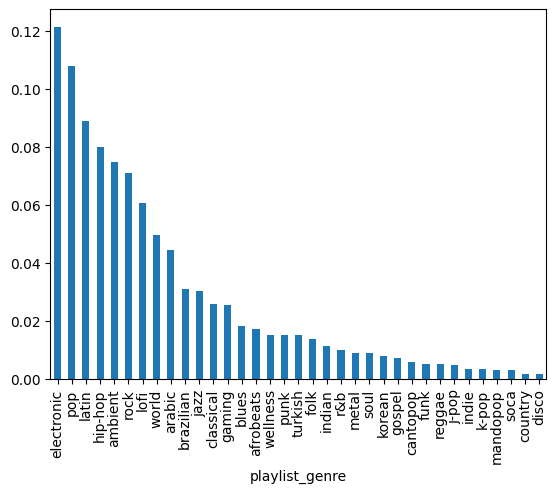

In [ ]:
distribution.plot(kind='bar')

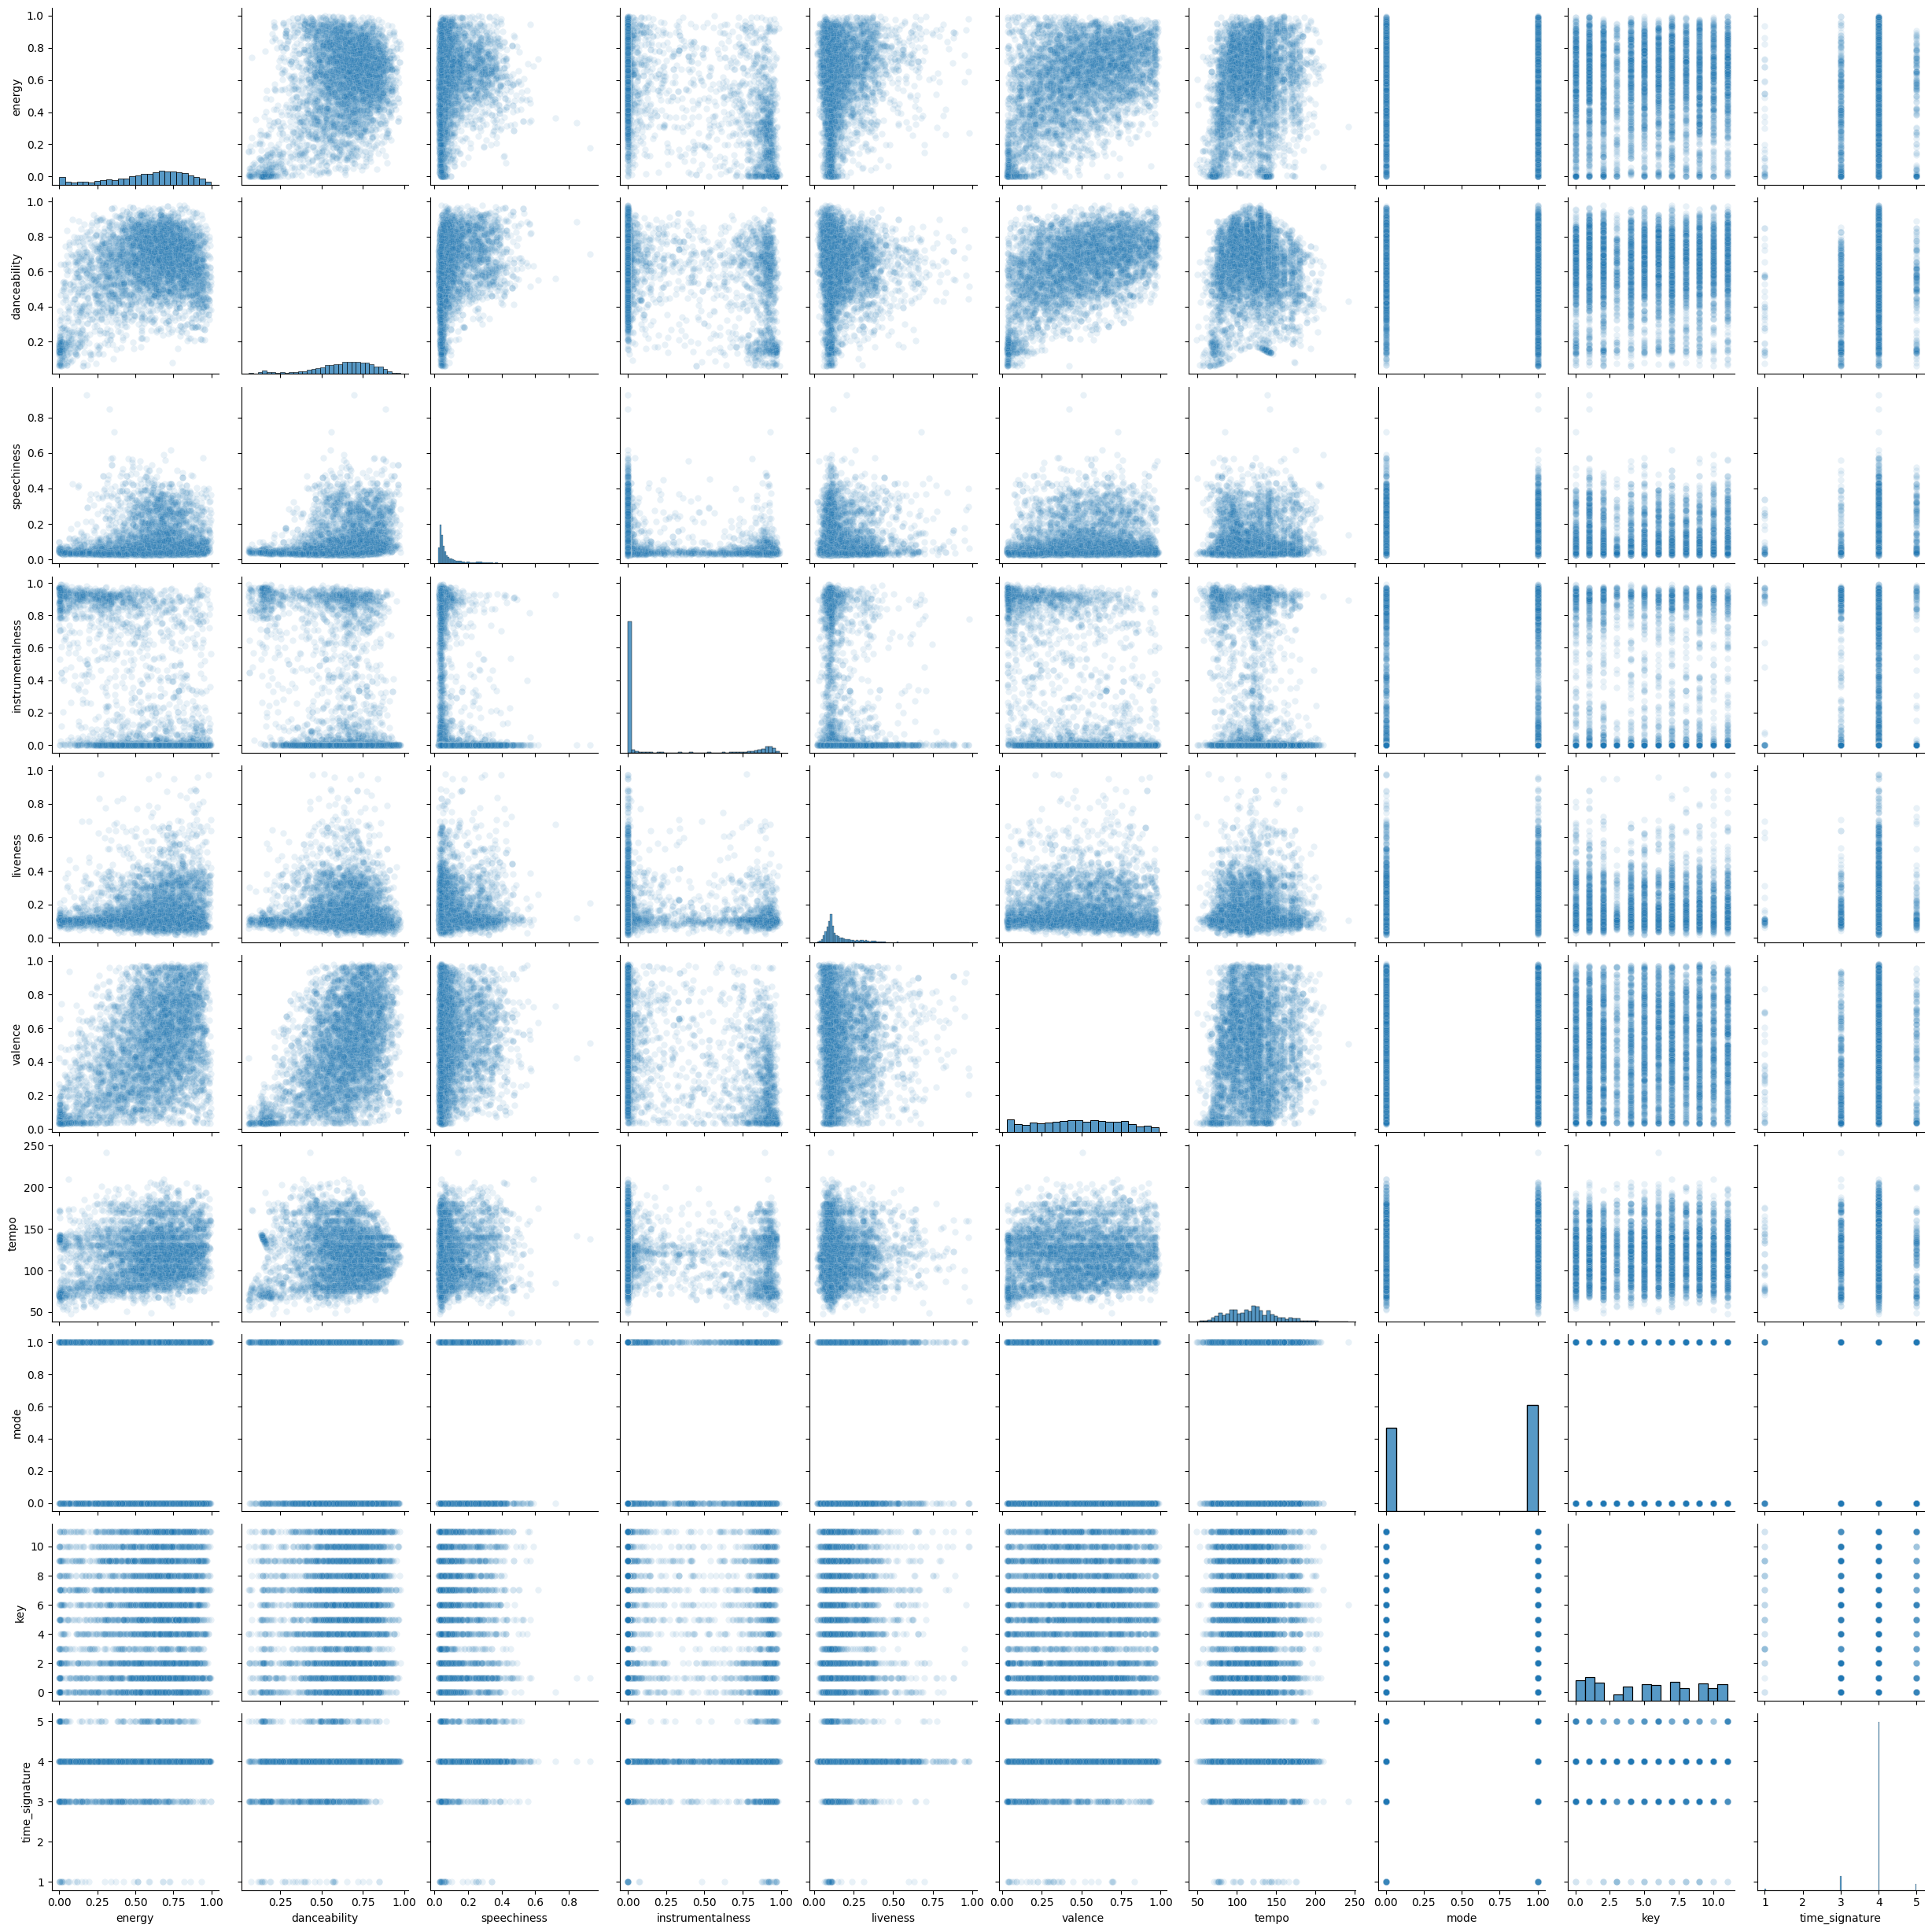

In [ ]:
sns.pairplot(df_spotify.loc[:,ft_space1+['playlist_genre']], plot_kws={'alpha':.1});

In [ ]:
ft_space0 = ['energy', 'danceability', 'valence', 'tempo']

In [ ]:
X_train_0 = X_train_full.loc[:, ft_space0]
X_test_0 = X_test_full.loc[:, ft_space0]

In [ ]:
rf0 = RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=0)
rf0.fit(X_train_0, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [ ]:
preds_rf0 = rf0.predict(X_test_0)

In [ ]:
print(classification_report(y_test, preds_rf0))

              precision    recall  f1-score   support

   afrobeats       0.40      0.22      0.29         9
     ambient       0.23      0.26      0.24        42
      arabic       0.17      0.16      0.16        19
       blues       0.00      0.00      0.00        10
   brazilian       0.26      0.31      0.29        16
    cantopop       0.00      0.00      0.00         2
   classical       0.36      0.45      0.40        11
     country       0.00      0.00      0.00         4
       disco       0.00      0.00      0.00         2
  electronic       0.37      0.40      0.38        75
        folk       0.00      0.00      0.00        10
        funk       0.00      0.00      0.00         6
      gaming       0.00      0.00      0.00        25
      gospel       0.50      0.25      0.33         8
     hip-hop       0.45      0.43      0.44        56
      indian       0.00      0.00      0.00         8
       indie       0.00      0.00      0.00         2
       j-pop       0.00    

/home/tijn/Downloads/archive(1)/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tijn/Downloads/archive(1)/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tijn/Downloads/archive(1)/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [ ]:
X_train_1 = X_train_full.loc[:, ft_space1]
X_test_1 = X_test_full.loc[:, ft_space1]

In [ ]:
rf1 = RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=0)
rf1.fit(X_train_1, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [ ]:
preds_rf1 = rf1.predict(X_test_1)

In [ ]:
print(classification_report(y_test, preds_rf1))

              precision    recall  f1-score   support

   afrobeats       0.33      0.11      0.17         9
     ambient       0.25      0.31      0.28        42
      arabic       0.27      0.21      0.24        19
       blues       0.00      0.00      0.00        10
   brazilian       0.50      0.25      0.33        16
    cantopop       0.00      0.00      0.00         2
   classical       0.57      0.73      0.64        11
     country       0.00      0.00      0.00         4
       disco       0.00      0.00      0.00         2
  electronic       0.49      0.48      0.49        75
        folk       0.20      0.10      0.13        10
        funk       1.00      0.33      0.50         6
      gaming       0.00      0.00      0.00        25
      gospel       0.50      0.12      0.20         8
     hip-hop       0.48      0.62      0.54        56
      indian       0.00      0.00      0.00         8
       indie       0.00      0.00      0.00         2
       j-pop       0.00    

/home/tijn/Downloads/archive(1)/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tijn/Downloads/archive(1)/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tijn/Downloads/archive(1)/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

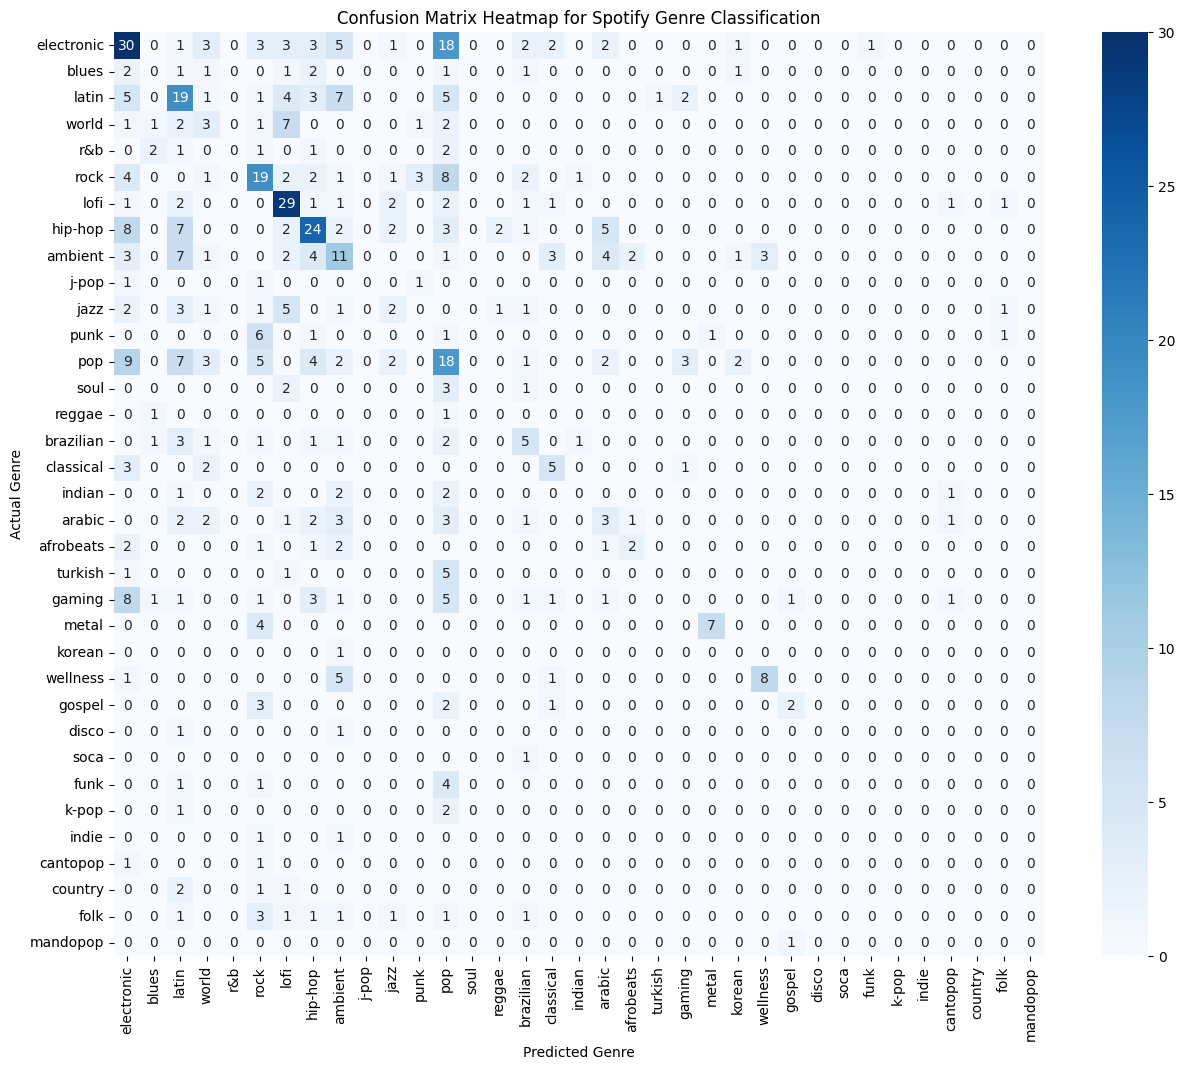

In [ ]:
# preds_rf0 = your predicted genres
cm = confusion_matrix(y_test, preds_rf0, labels=y_test.unique())

# Convert to a DataFrame for better plotting
cm_df = pd.DataFrame(cm, index=y_test.unique(), columns=y_test.unique())

plt.figure(figsize=(15, 12))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Confusion Matrix Heatmap for Spotify Genre Classification")
plt.ylabel("Actual Genre")
plt.xlabel("Predicted Genre")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [ ]:
# Observation: Model mispredicts pop for electronic and vice versa a significant amount, is there a way to introduce a new feature that distinguishes these two genres better?

In [ ]:
xgb_def = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_estimators=1000, n_jobs=-1, random_state=0)

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

xgb_def.fit(X_train_1, y_train_enc)

/home/tijn/Downloads/archive(1)/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [18:13:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [ ]:
preds_xgb_def = xgb_def.predict(X_test_1)

In [ ]:
print(classification_report(y_test_enc, preds_xgb_def))

              precision    recall  f1-score   support

           0       0.33      0.22      0.27         9
           1       0.25      0.36      0.30        42
           2       0.04      0.05      0.05        19
           3       0.00      0.00      0.00        10
           4       0.30      0.19      0.23        16
           5       0.00      0.00      0.00         2
           6       0.67      0.73      0.70        11
           7       0.00      0.00      0.00         4
           8       0.00      0.00      0.00         2
           9       0.46      0.45      0.46        75
          10       0.00      0.00      0.00        10
          11       0.50      0.17      0.25         6
          12       0.00      0.00      0.00        25
          13       1.00      0.38      0.55         8
          14       0.48      0.52      0.50        56
          15       0.00      0.00      0.00         8
          16       0.00      0.00      0.00         2
          17       0.00    

/home/tijn/Downloads/archive(1)/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tijn/Downloads/archive(1)/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tijn/Downloads/archive(1)/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [ ]:
xgb1 = xgb.XGBClassifier(n_estimators=5000, learning_rate=.01, eval_metric='mlogloss', use_label_encoder=False, n_jobs=-1, random_state=0)

3.2.0


In [ ]:
xgb1.fit(X_train_1, y_train_enc, eval_set=[(X_test_1, y_test_enc)], early_stopping_rounds = 10, verbose=True)

TypeError: XGBClassifier.fit() got an unexpected keyword argument 'callbacks'